# using for testing habitat-sim (since 2026.3.17)


Renderer: NVIDIA GeForce RTX 3060 Laptop GPU/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.133.07
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
agent_state: position [-10.   0.   1.] r

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[19:14:49:250198]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'default' : Lighting Layout Attributes 'no_lights' specified in Scene Attributes but does not exist in dataset, so creating default.
/tmp/ipykernel_12663/1331291105.py:33: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  rgb_img = Image.fromarray(rgb_obs, mode="RGBA")


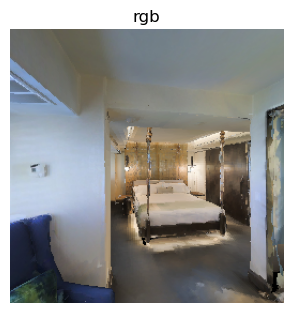

action:  turn_right


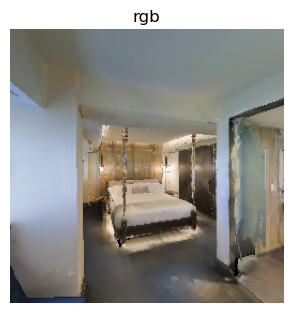

action:  move_forward


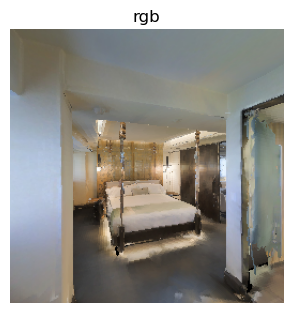

action:  turn_left


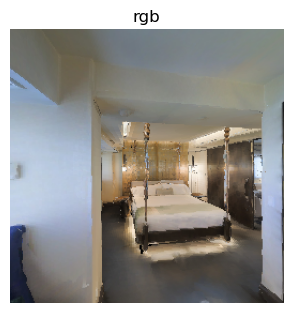

In [2]:
import math
import os
import random
import sys

import git
import imageio
import magnum as mn
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image

import habitat_sim
from habitat_sim.utils import common as utils
from habitat_sim.utils import viz_utils as vut

if "google.colab" in sys.modules:
    os.environ["IMAGEIO_FFMPEG_EXE"] = "/usr/bin/ffmpeg"

repo = git.Repo(".", search_parent_directories=True)
dir_path = repo.working_tree_dir

data_path = os.path.join(dir_path, "data")
output_directory = "examples/tutorials/nav_output/"
output_path = os.path.join(dir_path, output_directory)
if not os.path.exists(output_path):
    os.mkdir(output_path)


def display_sample(rgb_obs, semantic_obs=np.array([]), depth_obs=np.array([])):
    from habitat_sim.utils.common import d3_40_colors_rgb

    rgb_img = Image.fromarray(rgb_obs, mode="RGBA")

    arr = [rgb_img]
    titles = ["rgb"]
    if semantic_obs.size != 0:
        semantic_img = Image.new("P", (semantic_obs.shape[1], semantic_obs.shape[0]))
        semantic_img.putpalette(d3_40_colors_rgb.flatten())
        semantic_img.putdata((semantic_obs.flatten() % 40).astype(np.uint8))
        semantic_img = semantic_img.convert("RGBA")
        arr.append(semantic_img)
        titles.append("semantic")

    if depth_obs.size != 0:
        depth_img = Image.fromarray((depth_obs / 10 * 255).astype(np.uint8), mode="L")
        arr.append(depth_img)
        titles.append("depth")

    plt.figure(figsize=(12, 8))
    for i, data in enumerate(arr):
        ax = plt.subplot(1, 3, i + 1)
        ax.axis("off")
        ax.set_title(titles[i])
        plt.imshow(data)
    plt.show(block=False)


if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser()
    parser.add_argument("--no-display", dest="display", action="store_false")
    parser.add_argument("--no-make-video", dest="make_video", action="store_false")
    parser.set_defaults(show_video=True, make_video=True)
    args, _ = parser.parse_known_args()
    show_video = args.display
    display = args.display
    do_make_video = args.make_video
else:
    show_video = False
    do_make_video = False
    display = False


test_scene = "./data/scene_datasets/mp3d_example/17DRP5sb8fy/17DRP5sb8fy.glb"

sim_settings = {
    "scene": test_scene,
    # "scene_dataset": "./data/scene_datasets/mp3d_example/mp3d.scene_dataset_config.json",
    "default_agent": 0,
    "sensor_height": 1.5,
    "width": 256,
    "height": 256,
}


def make_simple_cfg(settings):
    sim_cfg = habitat_sim.SimulatorConfiguration()
    sim_cfg.scene_id = settings["scene"]
    # sim_cfg.scene_dataset_config_file = settings["scene_dataset"]

    agent_cfg = habitat_sim.agent.AgentConfiguration()

    # ✅ 修正：使用 CameraSensorSpec 取代舊版 SensorSpec
    rgb_sensor_spec = habitat_sim.CameraSensorSpec()
    rgb_sensor_spec.uuid = "color_sensor"
    rgb_sensor_spec.sensor_type = habitat_sim.SensorType.COLOR
    rgb_sensor_spec.resolution = [settings["height"], settings["width"]]
    rgb_sensor_spec.position = [0.0, settings["sensor_height"], 0.0]
    rgb_sensor_spec.sensor_subtype = habitat_sim.SensorSubType.PINHOLE  # ✅ 新增

    agent_cfg.sensor_specifications = [rgb_sensor_spec]

    return habitat_sim.Configuration(sim_cfg, [agent_cfg])


cfg = make_simple_cfg(sim_settings)

try:
    sim.close()
except NameError:
    pass
sim = habitat_sim.Simulator(cfg)

agent = sim.initialize_agent(sim_settings["default_agent"])

agent_state = habitat_sim.AgentState()
agent_state.position = np.array([-10.0, 0.0, 1.0])
agent.set_state(agent_state)

agent_state = agent.get_state()
print("agent_state: position", agent_state.position, "rotation", agent_state.rotation)

action_names = list(cfg.agents[sim_settings["default_agent"]].action_space.keys())
print("Discrete action space: ", action_names)


def navigateAndSee(action=""):
    if action in action_names:
        observations = sim.step(action)
        print("action: ", action)
        if display:
            display_sample(observations["color_sensor"])


action = "turn_right"
navigateAndSee(action)

action = "turn_right"
navigateAndSee(action)

action = "move_forward"
navigateAndSee(action)

action = "turn_left"
navigateAndSee(action)


# add sematic,depth camera

Renderer: NVIDIA GeForce RTX 3060 Laptop GPU/PCIe/SSE2 by NVIDIA Corporation
agent_state: position [-0.6  0.   0. ] rotation quaternion(1, 0, 0, 0)
Discrete action space:  ['move_forward', 'turn_left', 'turn_right']
OpenGL version: 4.6.0 NVIDIA 570.133.07
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[19:21:48:424988]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'mp3d' : Lighting Layout Attributes 'no_lights' specified in Scene Attributes but does not exist in dataset, so creating default.
/tmp/ipykernel_12663/3562312109.py:33: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  rgb_img = Image.fromarray(rgb_obs, mode="RGBA")
/tmp/ipykernel_12663/3562312109.py:46: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-1

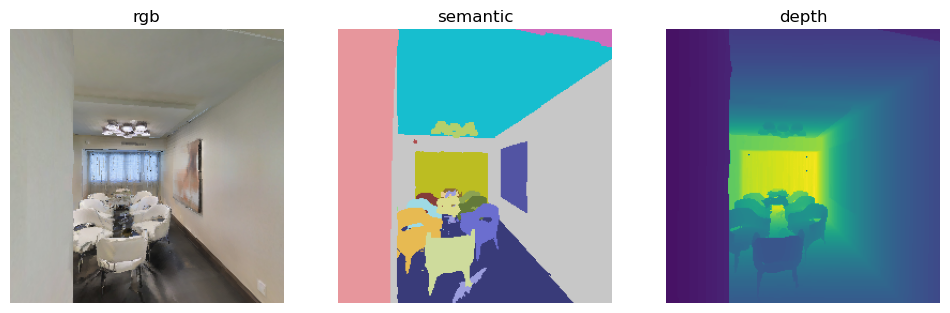

action:  turn_right


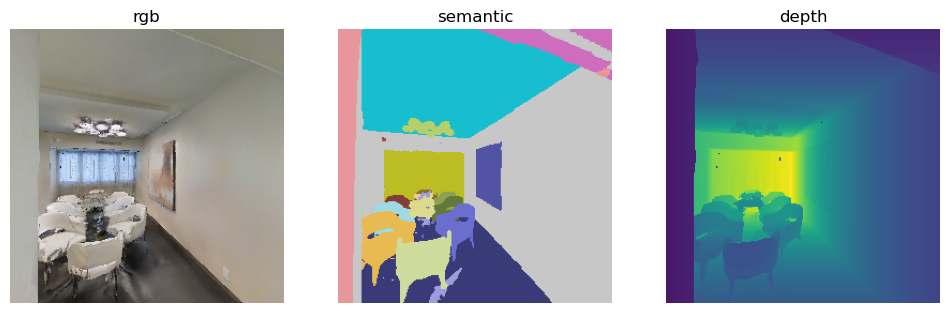

action:  move_forward


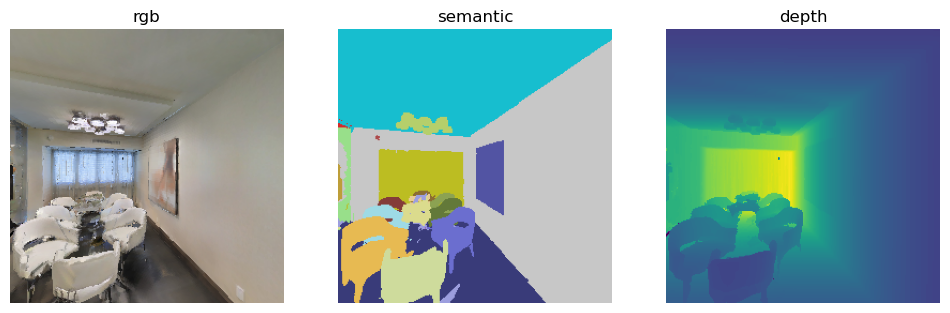

action:  turn_left


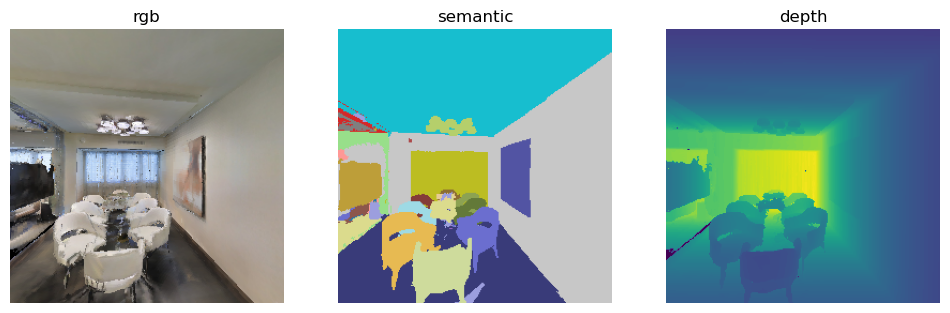

In [4]:
import math
import os
import random
import sys

import git
import imageio
import magnum as mn
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image

import habitat_sim
from habitat_sim.utils import common as utils
from habitat_sim.utils import viz_utils as vut

if "google.colab" in sys.modules:
    os.environ["IMAGEIO_FFMPEG_EXE"] = "/usr/bin/ffmpeg"

repo = git.Repo(".", search_parent_directories=True)
dir_path = repo.working_tree_dir

data_path = os.path.join(dir_path, "data")
output_directory = "examples/tutorials/nav_output/"
output_path = os.path.join(dir_path, output_directory)
if not os.path.exists(output_path):
    os.mkdir(output_path)


def display_sample(rgb_obs, semantic_obs=np.array([]), depth_obs=np.array([])):
    from habitat_sim.utils.common import d3_40_colors_rgb

    rgb_img = Image.fromarray(rgb_obs, mode="RGBA")

    arr = [rgb_img]
    titles = ["rgb"]
    if semantic_obs.size != 0:
        semantic_img = Image.new("P", (semantic_obs.shape[1], semantic_obs.shape[0]))
        semantic_img.putpalette(d3_40_colors_rgb.flatten())
        semantic_img.putdata((semantic_obs.flatten() % 40).astype(np.uint8))
        semantic_img = semantic_img.convert("RGBA")
        arr.append(semantic_img)
        titles.append("semantic")

    if depth_obs.size != 0:
        depth_img = Image.fromarray((depth_obs / 10 * 255).astype(np.uint8), mode="L")
        arr.append(depth_img)
        titles.append("depth")

    plt.figure(figsize=(12, 8))
    for i, data in enumerate(arr):
        ax = plt.subplot(1, 3, i + 1)
        ax.axis("off")
        ax.set_title(titles[i])
        plt.imshow(data)
    plt.show(block=False)


if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser()
    parser.add_argument("--no-display", dest="display", action="store_false")
    parser.add_argument("--no-make-video", dest="make_video", action="store_false")
    parser.set_defaults(show_video=True, make_video=True)
    args, _ = parser.parse_known_args()
    show_video = args.display
    display = args.display
    do_make_video = args.make_video
else:
    show_video = False
    do_make_video = False
    display = False


test_scene = "./data/scene_datasets/mp3d_example/17DRP5sb8fy/17DRP5sb8fy.glb"

rgb_sensor = True
depth_sensor = True
semantic_sensor = True

sim_settings = {
    "scene": test_scene,
    "scene_dataset": "./data/scene_datasets/mp3d_example/mp3d.scene_dataset_config.json",
    "default_agent": 0,
    "sensor_height": 1.5,
    "color_sensor": rgb_sensor,
    "depth_sensor": depth_sensor,
    "semantic_sensor": semantic_sensor,
    "width": 256,
    "height": 256,
}


def make_simple_cfg(settings):
    sim_cfg = habitat_sim.SimulatorConfiguration()
    sim_cfg.scene_id = settings["scene"]
    sim_cfg.scene_dataset_config_file = settings["scene_dataset"]


    sensors = {
        "color_sensor": {
            "sensor_type": habitat_sim.SensorType.COLOR,
            "resolution": [settings["height"], settings["width"]],
            "position": [0.0, settings["sensor_height"], 0.0],
        },
        "depth_sensor": {
            "sensor_type": habitat_sim.SensorType.DEPTH,
            "resolution": [settings["height"], settings["width"]],
            "position": [0.0, settings["sensor_height"], 0.0],
        },
        "semantic_sensor": {
            "sensor_type": habitat_sim.SensorType.SEMANTIC,
            "resolution": [settings["height"], settings["width"]],
            "position": [0.0, settings["sensor_height"], 0.0],
        },
    }

    sensor_specs = []
    for sensor_uuid, sensor_params in sensors.items():
        if settings[sensor_uuid]:
            sensor_spec = habitat_sim.CameraSensorSpec()                    # ✅ 修正5：SensorSpec → CameraSensorSpec
            sensor_spec.uuid = sensor_uuid
            sensor_spec.sensor_type = sensor_params["sensor_type"]
            sensor_spec.resolution = sensor_params["resolution"]
            sensor_spec.position = sensor_params["position"]
            sensor_spec.sensor_subtype = habitat_sim.SensorSubType.PINHOLE  # ✅ 修正6：新增

            sensor_specs.append(sensor_spec)
    agent_cfg = habitat_sim.agent.AgentConfiguration()
    agent_cfg.sensor_specifications = sensor_specs
    # ✅ 修正：使用 CameraSensorSpec 取代舊版 SensorSpec

    return habitat_sim.Configuration(sim_cfg, [agent_cfg])


cfg = make_simple_cfg(sim_settings)

try:
    sim.close()
except NameError:
    pass
sim = habitat_sim.Simulator(cfg)

agent = sim.initialize_agent(sim_settings["default_agent"])

agent_state = habitat_sim.AgentState()
agent_state.position = np.array([-0.6, 0.0, 0.0])
agent.set_state(agent_state)

agent_state = agent.get_state()
print("agent_state: position", agent_state.position, "rotation", agent_state.rotation)

action_names = list(cfg.agents[sim_settings["default_agent"]].action_space.keys())
print("Discrete action space: ", action_names)


def navigateAndSee(action=""):
    if action in action_names:
        observations = sim.step(action)
        rgb = observations["color_sensor"]
        semantic = observations["semantic_sensor"]
        depth = observations["depth_sensor"]
        print("action: ", action)
        if display:
            display_sample(rgb, semantic, depth)


action = "turn_right"
navigateAndSee(action)

action = "turn_right"
navigateAndSee(action)

action = "move_forward"
navigateAndSee(action)

action = "turn_left"
navigateAndSee(action)


# random walk

## *user input to control the agent*

Renderer: NVIDIA GeForce RTX 3060 Laptop GPU/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.133.07
House has 1 levels, 10 regions and 187 objects
House center:<bound method PyCapsule.center of Range({-11.5795, -0.113902, -5.9349}, {5.99388, 2.78846, 2.92465})> dims:Vector(17.5734, 2.90236, 8.85955)
Level id:0, center:<bound method PyCapsule.center of Range({-11.5072, -0.1139, -5.9349}, {5.19247, 2.78846, 2.92465})>, dims:Vector(16.6997, 2.90236, 8.85955)
Region id:0_0, category:bedroom, center:<bound method PyCapsule.center of Range({-10.9035, -0.00842166, -4.79521}, {-6.74019, 2.52724, -0.587867})>, dims:Vector(4.16331, 2.53566, 4.20734)
Object id:0_0_0, category:wall, center:<bound method PyCapsule.center of Range({-11.1602, -0.00897026, -5.0347}, {0, 2.57251, 0})>, dims:Vector(11.1602, 2.58148, 5.0347)
Object id:0_0_1, category:ceiling, center:<bound method PyCapsule.center of Range({-11.1514, 0, -5.03579}, {0, 2.55948, 0})>, dims:Vector(11.1514, 2.55948, 5.03579)


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[10:24:09:146974]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'mp3d' : Lighting Layout Attributes 'no_lights' specified in Scene Attributes but does not exist in dataset, so creating default.


action turn_right


/tmp/ipykernel_7973/477965608.py:33: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  rgb_img = Image.fromarray(rgb_obs, mode="RGBA")
/tmp/ipykernel_7973/477965608.py:46: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  depth_img = Image.fromarray((depth_obs / 10 * 255).astype(np.uint8), mode="L")


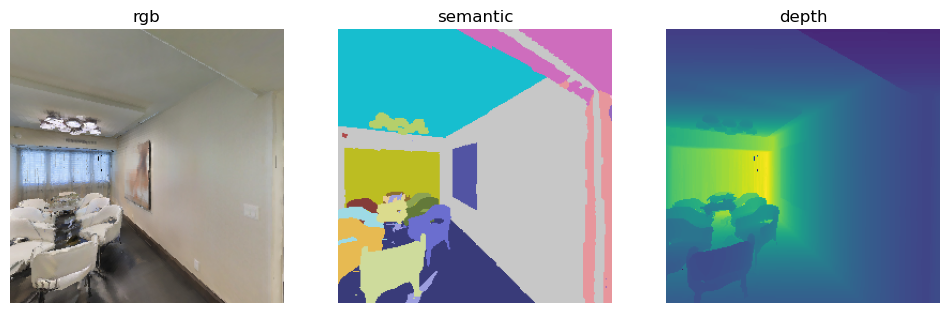

action turn_right


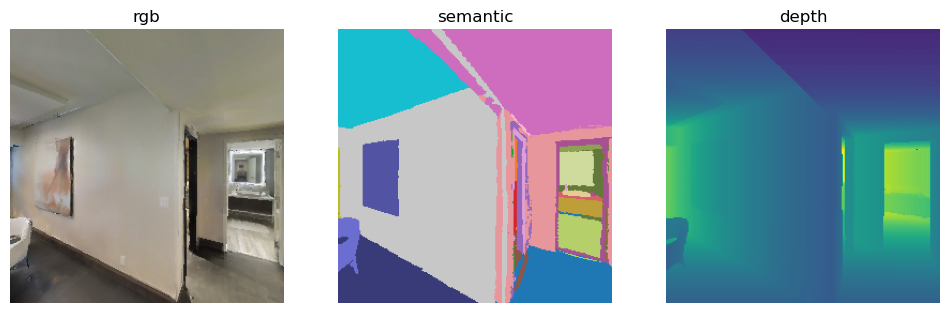

action turn_right


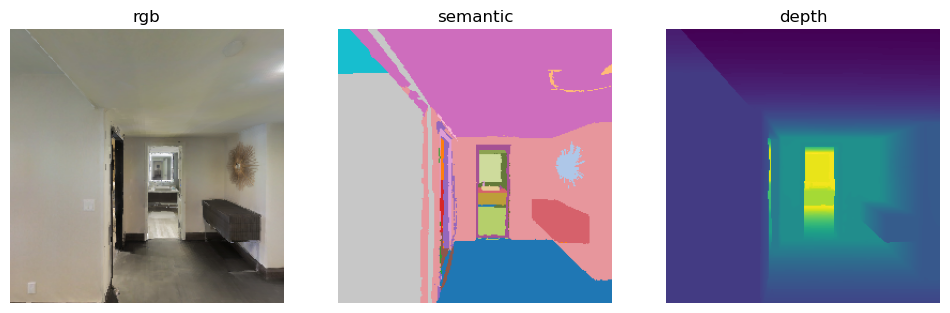

action 


AssertionError: No action  in action space

In [3]:
import math
import os
import random
import sys

import git
import imageio
import magnum as mn
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image

import habitat_sim
from habitat_sim.utils import common as utils
from habitat_sim.utils import viz_utils as vut

if "google.colab" in sys.modules:
    os.environ["IMAGEIO_FFMPEG_EXE"] = "/usr/bin/ffmpeg"

repo = git.Repo(".", search_parent_directories=True)
dir_path = repo.working_tree_dir

data_path = os.path.join(dir_path, "data")
output_directory = "examples/tutorials/nav_output/"
output_path = os.path.join(dir_path, output_directory)
if not os.path.exists(output_path):
    os.mkdir(output_path)


def display_sample(rgb_obs, semantic_obs=np.array([]), depth_obs=np.array([])):
    from habitat_sim.utils.common import d3_40_colors_rgb

    rgb_img = Image.fromarray(rgb_obs, mode="RGBA")

    arr = [rgb_img]
    titles = ["rgb"]
    if semantic_obs.size != 0:
        semantic_img = Image.new("P", (semantic_obs.shape[1], semantic_obs.shape[0]))
        semantic_img.putpalette(d3_40_colors_rgb.flatten())
        semantic_img.putdata((semantic_obs.flatten() % 40).astype(np.uint8))
        semantic_img = semantic_img.convert("RGBA")
        arr.append(semantic_img)
        titles.append("semantic")

    if depth_obs.size != 0:
        depth_img = Image.fromarray((depth_obs / 10 * 255).astype(np.uint8), mode="L")
        arr.append(depth_img)
        titles.append("depth")

    plt.figure(figsize=(12, 8))
    for i, data in enumerate(arr):
        ax = plt.subplot(1, 3, i + 1)
        ax.axis("off")
        ax.set_title(titles[i])
        plt.imshow(data)
    plt.show(block=False)


if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser()
    parser.add_argument("--no-display", dest="display", action="store_false")
    parser.add_argument("--no-make-video", dest="make_video", action="store_false")
    parser.set_defaults(show_video=True, make_video=True)
    args, _ = parser.parse_known_args()
    show_video = args.display
    display = args.display
    do_make_video = args.make_video
else:
    show_video = False
    do_make_video = False
    display = False


# ✅ 修正1：路徑改為 mp3d_example
test_scene = "./data/scene_datasets/mp3d_example/17DRP5sb8fy/17DRP5sb8fy.glb"

rgb_sensor = True
depth_sensor = True
semantic_sensor = True

sim_settings = {
    "width": 256,
    "height": 256,
    "scene": test_scene,
    "scene_dataset": "./data/scene_datasets/mp3d_example/mp3d.scene_dataset_config.json",  # ✅ 修正2：新增
    "default_agent": 0,
    "sensor_height": 1.5,
    "color_sensor": rgb_sensor,
    "depth_sensor": depth_sensor,
    "semantic_sensor": semantic_sensor,
    "seed": 1,
    "enable_physics": False,
}


def make_cfg(settings):
    sim_cfg = habitat_sim.SimulatorConfiguration()
    sim_cfg.gpu_device_id = 0
    sim_cfg.scene_id = settings["scene"]                                    # ✅ 修正3：scene.id → scene_id
    sim_cfg.scene_dataset_config_file = settings["scene_dataset"]           # ✅ 修正4：新增
    sim_cfg.enable_physics = settings["enable_physics"]

    sensors = {
        "color_sensor": {
            "sensor_type": habitat_sim.SensorType.COLOR,
            "resolution": [settings["height"], settings["width"]],
            "position": [0.0, settings["sensor_height"], 0.0],
        },
        "depth_sensor": {
            "sensor_type": habitat_sim.SensorType.DEPTH,
            "resolution": [settings["height"], settings["width"]],
            "position": [0.0, settings["sensor_height"], 0.0],
        },
        "semantic_sensor": {
            "sensor_type": habitat_sim.SensorType.SEMANTIC,
            "resolution": [settings["height"], settings["width"]],
            "position": [0.0, settings["sensor_height"], 0.0],
        },
    }

    sensor_specs = []
    for sensor_uuid, sensor_params in sensors.items():
        if settings[sensor_uuid]:
            sensor_spec = habitat_sim.CameraSensorSpec()                    # ✅ 修正5：SensorSpec → CameraSensorSpec
            sensor_spec.uuid = sensor_uuid
            sensor_spec.sensor_type = sensor_params["sensor_type"]
            sensor_spec.resolution = sensor_params["resolution"]
            sensor_spec.position = sensor_params["position"]
            sensor_spec.sensor_subtype = habitat_sim.SensorSubType.PINHOLE  # ✅ 修正6：新增

            sensor_specs.append(sensor_spec)

    agent_cfg = habitat_sim.agent.AgentConfiguration()
    agent_cfg.sensor_specifications = sensor_specs
    agent_cfg.action_space = {
        "move_forward": habitat_sim.agent.ActionSpec(
            "move_forward", habitat_sim.agent.ActuationSpec(amount=0.25)
        ),
        "turn_left": habitat_sim.agent.ActionSpec(
            "turn_left", habitat_sim.agent.ActuationSpec(amount=30.0)
        ),
        "turn_right": habitat_sim.agent.ActionSpec(
            "turn_right", habitat_sim.agent.ActuationSpec(amount=30.0)
        ),
    }

    return habitat_sim.Configuration(sim_cfg, [agent_cfg])


cfg = make_cfg(sim_settings)
try:
    sim.close()
except NameError:
    pass
sim = habitat_sim.Simulator(cfg)
def print_scene_recur(scene, limit_output=10):
    print(
        f"House has {len(scene.levels)} levels, {len(scene.regions)} regions and {len(scene.objects)} objects"
    )
    print(f"House center:{scene.aabb.center} dims:{scene.aabb.size()}")  # ✅ .sizes → .size()

    count = 0
    for level in scene.levels:
        print(
            f"Level id:{level.id}, center:{level.aabb.center},"
            f" dims:{level.aabb.size()}"                                  # ✅ .sizes → .size()
        )
        for region in level.regions:
            print(
                f"Region id:{region.id}, category:{region.category.name()},"
                f" center:{region.aabb.center}, dims:{region.aabb.size()}"  # ✅ .sizes → .size()
            )
            for obj in region.objects:
                print(
                    f"Object id:{obj.id}, category:{obj.category.name()},"
                    f" center:{obj.aabb.center}, dims:{obj.aabb.size()}"    # ✅ .sizes → .size()
                )
                count += 1
                if count >= limit_output:
                    return None


scene = sim.semantic_scene
print_scene_recur(scene)


random.seed(None)
sim.seed(random.randint(0, 2**32 - 1))

agent = sim.initialize_agent(sim_settings["default_agent"])
agent_state = habitat_sim.AgentState()
agent_state.position = np.array([-0.6, 0.0, 0.0])
agent.set_state(agent_state)

agent_state = agent.get_state()
print("agent_state: position", agent_state.position, "rotation", agent_state.rotation)

total_frames = 0
action_names = list(cfg.agents[sim_settings["default_agent"]].action_space.keys())
max_frames = 5

# while total_frames < max_frames:
#     action = random.choice(action_names)
#     print("action", action)
#     observations = sim.step(action)
#     rgb = observations["color_sensor"]
#     semantic = observations["semantic_sensor"]
#     depth = observations["depth_sensor"]

#     if display:
#         display_sample(rgb, semantic, depth)

#     total_frames += 1

while 1:
    action = input("Enter action (move_forward, turn_left, turn_right): quit to exit: ")
    if action == "quit":
        break
    print("action", action)
    observations = sim.step(action)
    rgb = observations["color_sensor"]
    semantic = observations["semantic_sensor"]
    depth = observations["depth_sensor"]

    if display:
        display_sample(rgb, semantic, depth)


<H1> Working with the NavMesh </H1>